In [1]:
import numpy as np

In [2]:
# step activation function
def step(z):
    return 1 if z > 0 else 0

In [35]:
# XOR Neural Network

class Adaline:
    def __init__(self, learning_rate=0.001, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = np.array([1.0, 1.0, 1.0])  # initial weights
        self.bias = -0.8                           # initial bias

    def net_input(self, X):
        return np.dot(X, self.weights) + self.bias

    def fit(self, X, y):
        for epoch in range(self.epochs):
            output = self.net_input(X)
            error = y - output

            # Weight and bias update (gradient descent)
            self.weights += self.lr * np.dot(X.T, error)
            self.bias += self.lr * error.sum()

            mse = np.mean(error ** 2)
            print(f"Epoch {epoch+1}, MSE: {mse:.4f}")

    def predict(self, X):
        return self.net_input(X)

In [36]:
# Input data (3 inputs per sample)
X = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])

In [37]:
# Target values
y = np.array([0, 0, 0, 1, 0, 1, 1, 1])

In [38]:
# Train Adaline
adaline = Adaline(learning_rate=0.001, epochs=20)
adaline.fit(X, y)

Epoch 1, MSE: 0.2900
Epoch 2, MSE: 0.2870
Epoch 3, MSE: 0.2840
Epoch 4, MSE: 0.2811
Epoch 5, MSE: 0.2783
Epoch 6, MSE: 0.2756
Epoch 7, MSE: 0.2729
Epoch 8, MSE: 0.2703
Epoch 9, MSE: 0.2678
Epoch 10, MSE: 0.2653
Epoch 11, MSE: 0.2629
Epoch 12, MSE: 0.2606
Epoch 13, MSE: 0.2584
Epoch 14, MSE: 0.2561
Epoch 15, MSE: 0.2540
Epoch 16, MSE: 0.2519
Epoch 17, MSE: 0.2499
Epoch 18, MSE: 0.2479
Epoch 19, MSE: 0.2460
Epoch 20, MSE: 0.2441


## MSE is monotonically decreasing
### Epoch 1  → 1.2500
### Epoch 10 → 0.9739
### Epoch 20 → 0.7431

#### This shows that:
#### The error is reducing each epoch Gradient descent is working The learning rate is appropriate

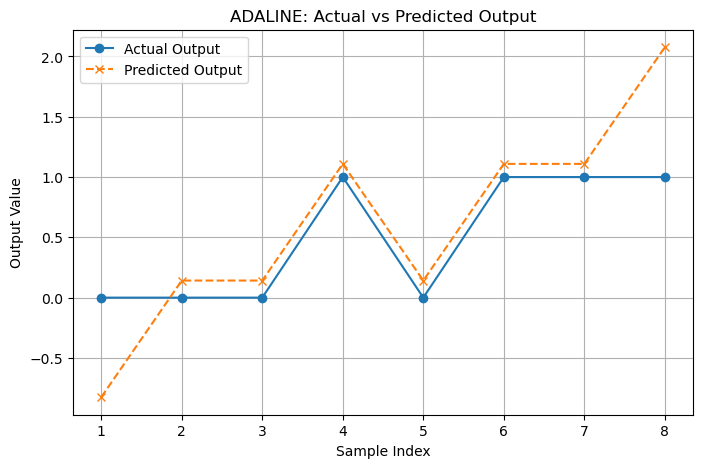

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Actual target values
y = np.array([0, 0, 0, 1, 0, 1, 1, 1])

# Predicted values from trained Adaline
y_pred = adaline.predict(X)

# Sample index
samples = np.arange(1, len(y) + 1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(samples, y, marker='o', label='Actual Output')
plt.plot(samples, y_pred, marker='x', linestyle='--', label='Predicted Output')

plt.xlabel('Sample Index')
plt.ylabel('Output Value')
plt.title('ADALINE: Actual vs Predicted Output')
plt.legend()
plt.grid(True)

plt.show()

## Batch Learning

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Training data
X = torch.tensor([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0],
    [0.0, 1.0, 0.0],
    [0.0, 1.0, 1.0],
    [1.0, 0.0, 0.0],
    [1.0, 0.0, 1.0],
    [1.0, 1.0, 0.0],
    [1.0, 1.0, 1.0]
])

y = torch.tensor([[0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0]])

In [45]:
def train_adaline(lr, epochs=50):
    model = nn.Linear(3, 1, bias=True)

    # Initialize weights to [1,1,1] and bias to 1
    with torch.no_grad():
        model.weight.copy_(torch.tensor([[1.0, 1.0, 1.0]]))
        model.bias.copy_(torch.tensor([1.0]))

    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    mse_history = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        mse_history.append(loss.item())

    final_weights = model.weight.detach().numpy()
    final_bias = model.bias.detach().numpy()

    return mse_history, final_weights, final_bias

In [46]:
learning_rates = [0.5, 0.1, 0.001]
results = {}

for lr in learning_rates:
    mse, w, b = train_adaline(lr)
    results[lr] = (mse, w, b)

C:\Users\jariw\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1, 8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


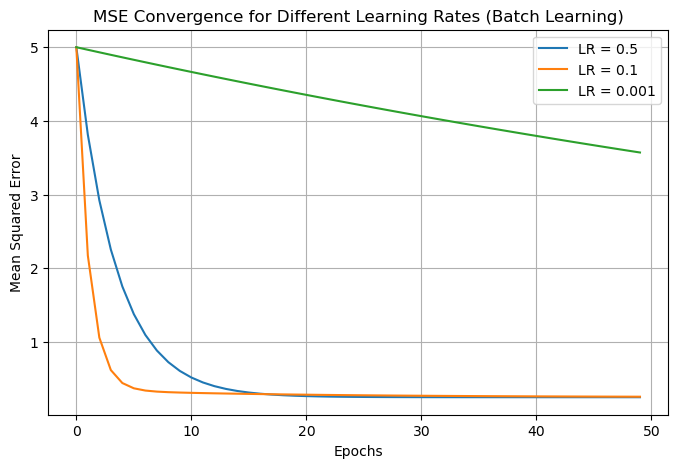

In [47]:
plt.figure(figsize=(8, 5))

for lr in learning_rates:
    plt.plot(results[lr][0], label=f"LR = {lr}")

plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("MSE Convergence for Different Learning Rates (Batch Learning)")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
for lr in learning_rates:
    mse, w, b = results[lr]
    print(f"\nLearning Rate = {lr}")
    print("Final Weights:", w)
    print("Final Bias:", b)


Learning Rate = 0.5
Final Weights: [[0.00075254 0.00075254 0.00075254]]
Final Bias: [0.5003762]

Learning Rate = 0.1
Final Weights: [[0.0914653 0.0914653 0.0914653]]
Final Bias: [0.34157744]

Learning Rate = 0.001
Final Weights: [[0.8853964 0.8853964 0.8853964]]
Final Bias: [0.8178988]


### Learning Rate = 0.5
##### Very fast updates
##### divergence or oscillation (In Excel Sheet I used LR as 0.5 which shows divergence means Gradient Descent is not working)
##### MSE is increases or fluctuates

### Learning Rate = 0.1
##### Faster convergence
##### Stable if lucky
##### oscillate slightly

### Learning Rate = 0.001
##### Slow but stable convergence
##### Smooth MSE curve
##### Best choice for ADALINE

##### Batch learning using a linear PyTorch model and MSE loss was performed for different learning rates. A high learning rate caused instability, while a small learning rate resulted in smooth convergence. The MSE vs epoch curves clearly demonstrate the effect of learning rate on convergence behavior.

# Mini Batch Learning

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Inputs: all 8 combinations of 3 binary inputs
X = torch.tensor([
    [0., 0., 0.],
    [0., 0., 1.],
    [0., 1., 0.],
    [0., 1., 1.],
    [1., 0., 0.],
    [1., 0., 1.],
    [1., 1., 0.],
    [1., 1., 1.]
])

# Example target values (can be any linear task)
y = torch.tensor([
    [0.],
    [1.],
    [1.],
    [0.],
    [1.],
    [0.],
    [0.],
    [1.]
])


In [50]:
def train_adaline_minibatch(lr, batch_size, epochs=50):
    model = nn.Linear(3, 1, bias=True)

    # Initialize weights and bias
    with torch.no_grad():
        model.weight.copy_(torch.tensor([[1.0, 1.0, 1.0]]))
        model.bias.copy_(torch.tensor([1.0]))

    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    mse_history = []

    n_samples = X.shape[0]

    for epoch in range(epochs):
        permutation = torch.randperm(n_samples)
        epoch_loss = 0.0

        for i in range(0, n_samples, batch_size):
            indices = permutation[i:i+batch_size]
            X_batch = X[indices]
            y_batch = y[indices]

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * len(X_batch)

        mse_history.append(epoch_loss / n_samples)

    final_weights = model.weight.detach().numpy()
    final_bias = model.bias.detach().numpy()

    return mse_history, final_weights, final_bias


In [51]:
learning_rates = [0.5, 0.1, 0.001]
batch_sizes = [2, 4]

results = {}

for bs in batch_sizes:
    for lr in learning_rates:
        mse, w, b = train_adaline_minibatch(lr, bs)
        results[(bs, lr)] = (mse, w, b)

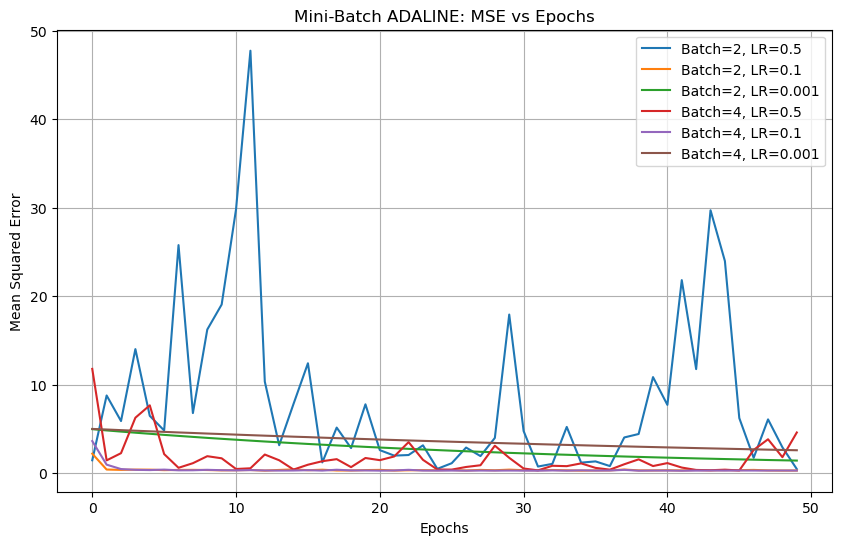

In [52]:
plt.figure(figsize=(10, 6))

for bs in batch_sizes:
    for lr in learning_rates:
        mse = results[(bs, lr)][0]
        plt.plot(mse, label=f"Batch={bs}, LR={lr}")

plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Mini-Batch ADALINE: MSE vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
for bs in batch_sizes:
    for lr in learning_rates:
        mse, w, b = results[(bs, lr)]
        print(f"\nBatch Size = {bs}, Learning Rate = {lr}")
        print("Final Weights:", w)
        print("Final Bias:", b)


Batch Size = 2, Learning Rate = 0.5
Final Weights: [[-0.26291388  0.0541245   0.20785883]]
Final Bias: [-0.06594276]

Batch Size = 2, Learning Rate = 0.1
Final Weights: [[-0.00875529  0.00089833 -0.0199517 ]]
Final Bias: [0.50155354]

Batch Size = 2, Learning Rate = 0.001
Final Weights: [[0.641876  0.6419803 0.6420314]]
Final Bias: [0.44425735]

Batch Size = 4, Learning Rate = 0.5
Final Weights: [[0.12615043 0.21551347 0.41831195]]
Final Bias: [1.7625477]

Batch Size = 4, Learning Rate = 0.1
Final Weights: [[-0.0004599   0.02096146  0.01606687]]
Final Bias: [0.44455627]

Batch Size = 4, Learning Rate = 0.001
Final Weights: [[0.7895587  0.7895535  0.78954023]]
Final Bias: [0.6681107]


#### Conclusion:
##### Mini-batch learning updates weights using subsets of training samples, providing a trade-off between stability and convergence speed. Smaller batch sizes introduce noise but improve generalization, while larger batches produce smoother convergence. Learning rate strongly influences stability, with smaller values ensuring convergence for the ADALINE network.

# Performance Analysis